# 2. Introducción a las Redes Neuronales Convolucionales

En esta sesión vamos a introducirnos en el mundo de las redes neuronales convolucionales (CNN), veremos las ventajas que estas nos ofrecen al trabajar con problemas de visión por computador frente a las redes neuronales totalmente conectadas.

Para esto vamos a trabajar con la base de datos [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html). Se trata de una base de datos de 50.000 muestras de entrenamiento y 10.000 muestras de test. Éstas representan imágenes de la vida cotidiana pertenecientes a 10 clases diferentes, por tanto, el principal objetivo es, dada una imagen, predecir la clase a la que pertenece. Las clases que podemos encontrar son: avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco y camión.

Uno de las principales desventajas con las que hay que lidiar en esta base de datos es el tamaño de las imágenes (32x32), por lo tanto, son imágenes con baja resolución.

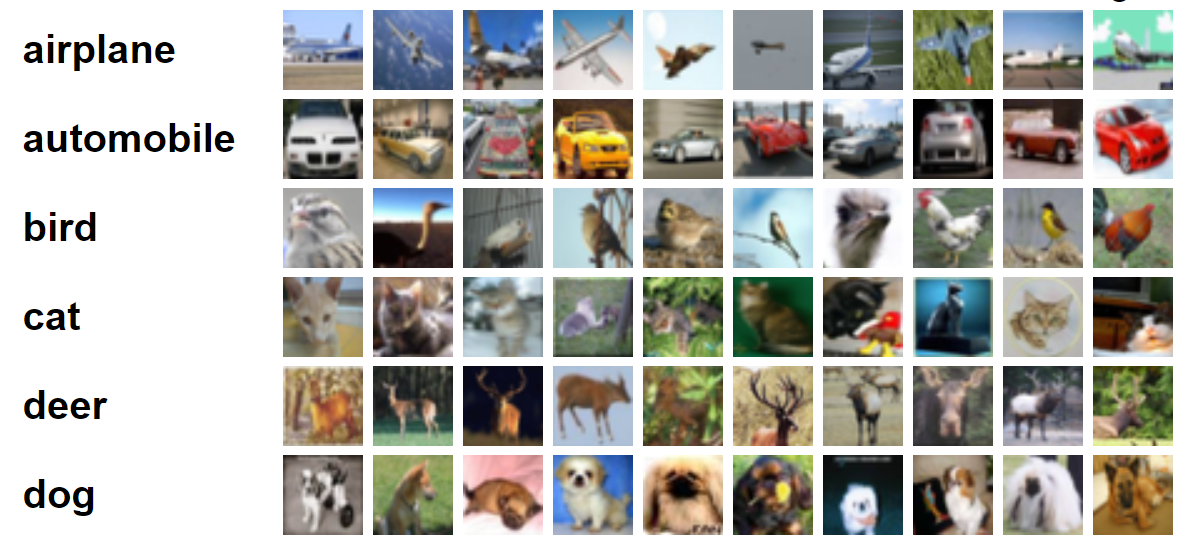

En primer lugar vamos a preparar los diferentes conjuntos de datos (entrenamiento, validación y test) con los que vamos a trabajar de igual modo que hemos realizado en sesiones anteriores. A continuación preprocesaremos las imágenes previo a ser empleadas en la red neuronal.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import time
import gc
from sklearn.model_selection import train_test_split

from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Flatten, Dense, Conv2D, MaxPool2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
# Clasificación -> Lineal -> Categóricos

cifar = keras.datasets.cifar10
(X_train_val, y_train_val), (X_test, y_test) = cifar.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


/tmp/ipython-input-3767312137.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f'{classes[int(y_train_val[j])]}')


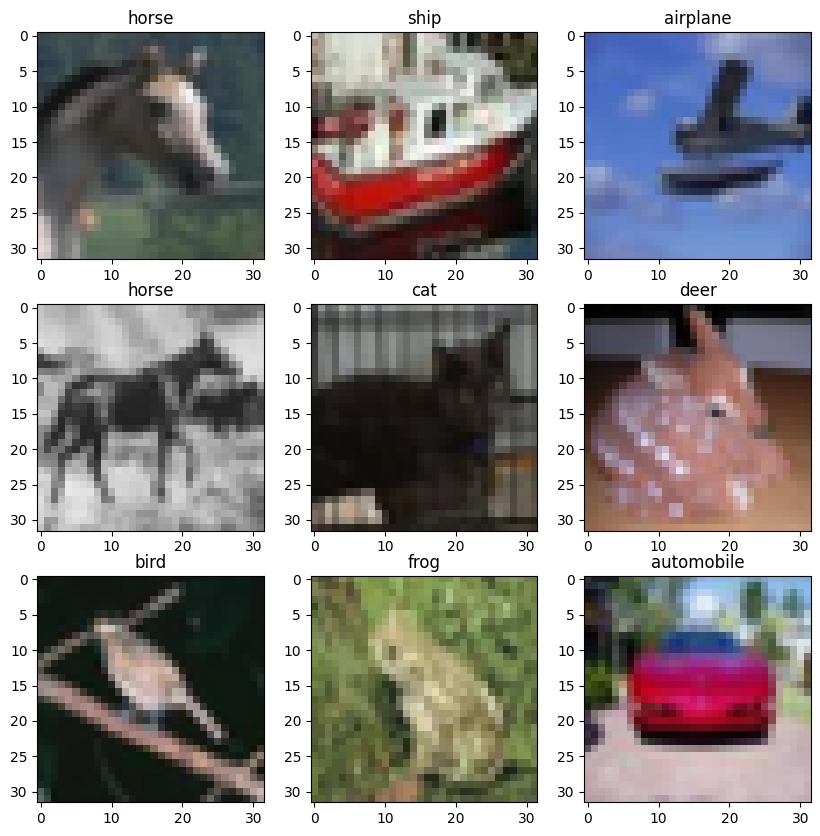

In [4]:
# Visualizamos las imágenes disponibles en la base de datos

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog',
           'horse', "ship", "truck"]

plt.figure(figsize=(10, 10))
# Mostramos 9 imágenes aleatorias con su etiqueta correspondiente
for i in range(9):
  plt.subplot(3, 3, i+1)
  j = np.random.randint(0, X_train_val.shape[0])
  plt.imshow(X_train_val[j])
  plt.title(f'{classes[int(y_train_val[j])]}')

Podemos observar la baja calidad de las imágenes. Algunas de ellas apenas se consigue reconocer a simple vista la clase a la que pertenecen.

| Conjunto       | Uso                                      | ¿El modelo aprende de él? |
| -------------- | ---------------------------------------- | ------------------------- |
| **Train**      | Ajustar pesos                            | ✔️ Sí                     |
| **Validation** | Ajustes, hiperparámetros, early stopping | ❌ No                      |
| **Test**       | Evaluación final                         | ❌ No                      |


In [5]:
# Diferenciamos entre entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2)

print('Tamaño datos entrenamiento: ', X_train.shape)
print('Tamaño datos validación: ', X_val.shape)
print('Tamaño datos test: ', X_test.shape)

print('Tamaño etiquetas entrenamiento: ', y_train.shape)
print('Tamaño etiquetas validación: ', y_val.shape)
print('Tamaño etiquetas test: ', y_test.shape)

Tamaño datos entrenamiento:  (40000, 32, 32, 3)
Tamaño datos validación:  (10000, 32, 32, 3)
Tamaño datos test:  (10000, 32, 32, 3)
Tamaño etiquetas entrenamiento:  (40000, 1)
Tamaño etiquetas validación:  (10000, 1)
Tamaño etiquetas test:  (10000, 1)


In [6]:
# Evaluamos el número registros que tenemos para cada clase
unique, counts = np.unique(y_train, return_counts=True)
print('Entrenamiento: ')
print(dict(zip(unique, counts)))
unique, counts = np.unique(y_val, return_counts=True)
print('Validación: ')
print(dict(zip(unique, counts)))
unique, counts = np.unique(y_test, return_counts=True)
print('Test: ')
print(dict(zip(unique, counts)))

Entrenamiento: 
{np.uint8(0): np.int64(4007), np.uint8(1): np.int64(3954), np.uint8(2): np.int64(4088), np.uint8(3): np.int64(4029), np.uint8(4): np.int64(3944), np.uint8(5): np.int64(3969), np.uint8(6): np.int64(4014), np.uint8(7): np.int64(3996), np.uint8(8): np.int64(3981), np.uint8(9): np.int64(4018)}
Validación: 
{np.uint8(0): np.int64(993), np.uint8(1): np.int64(1046), np.uint8(2): np.int64(912), np.uint8(3): np.int64(971), np.uint8(4): np.int64(1056), np.uint8(5): np.int64(1031), np.uint8(6): np.int64(986), np.uint8(7): np.int64(1004), np.uint8(8): np.int64(1019), np.uint8(9): np.int64(982)}
Test: 
{np.uint8(0): np.int64(1000), np.uint8(1): np.int64(1000), np.uint8(2): np.int64(1000), np.uint8(3): np.int64(1000), np.uint8(4): np.int64(1000), np.uint8(5): np.int64(1000), np.uint8(6): np.int64(1000), np.uint8(7): np.int64(1000), np.uint8(8): np.int64(1000), np.uint8(9): np.int64(1000)}


Observamos balanceo entre las clases en todos los subconjuntos de datos.

In [7]:
print('Rango valores intensidad: ', X_train.min(), '-', X_train.max())

Rango valores intensidad:  0 - 255


In [8]:
# Vemos que las imágenes están en un rango [0-255], para incorporarlas a la red debemos de cambiar su rango a [0-1]
X_train = X_train.astype('float32') / 255
X_val = X_val.astype('float32') / 255
X_test = X_test.astype('float32') / 255

print('Nuevo rango valores intensidad: ', X_train.min(), '-', X_train.max())

Nuevo rango valores intensidad:  0.0 - 1.0


## Red Neuronal Totalmente Conectada

En primer lugar vamos a abordar el problema empleando una red neuronal totalmente conectada (sin filtros convolucionales). Para ello, cada uno de los píxeles de la imagen serán tomadas como características de la entrada. Así, construiremos una arquitectura similar a la diseñada en las sesiones anteriores, donde tengamos una capa de entrada con 3072 nodos (32x32x3), una capa oculta con 128 nodos y una capa de salida con 10 nodos (uno por etiqueta).

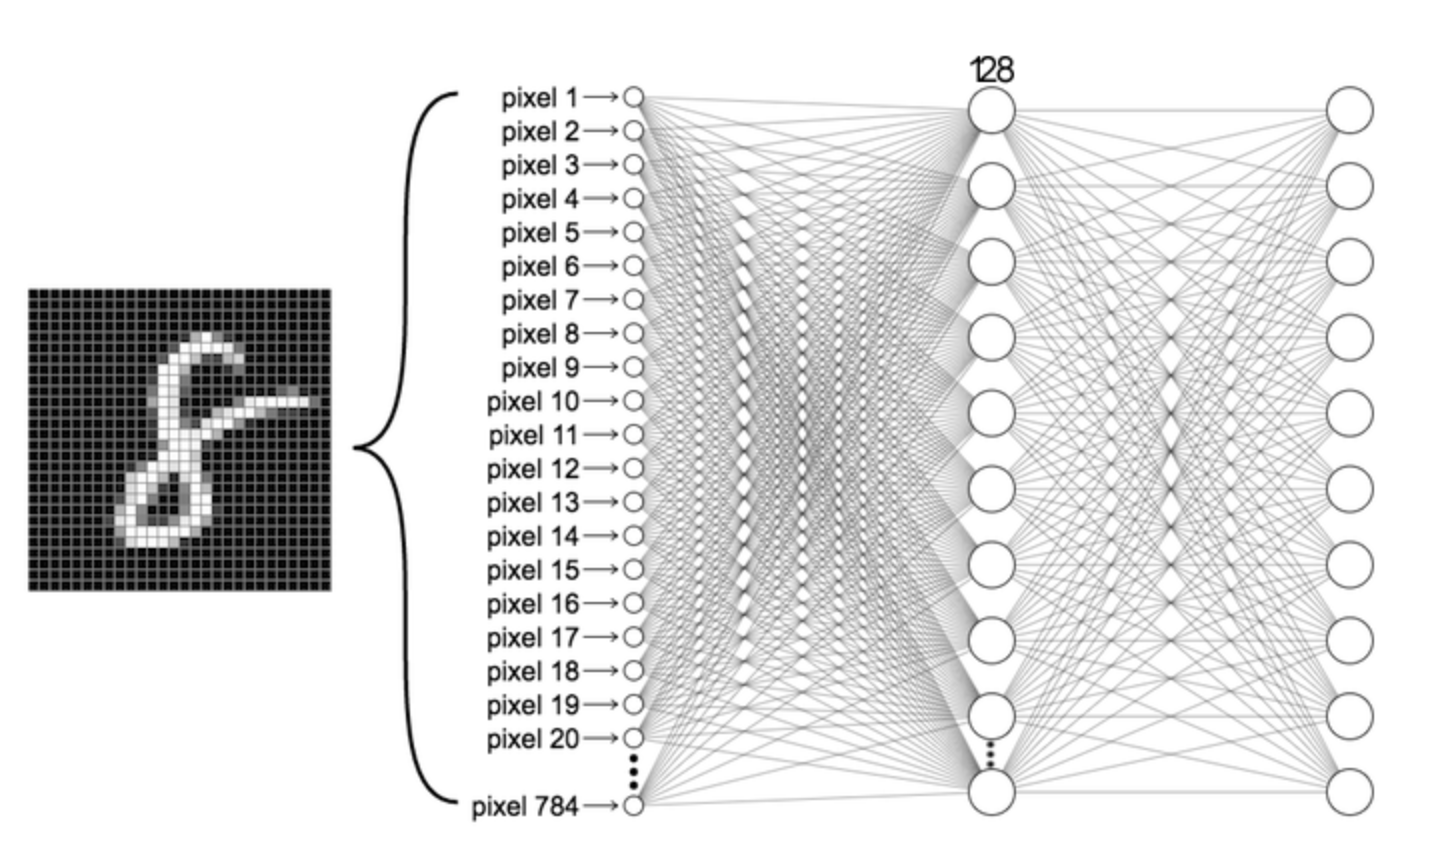

In [9]:
# Creamos método para la definición de la arquitetura

def create_fc_network():

  model = Sequential()
  model.add(Input(shape=X_train.shape[1:]))
  model.add(Flatten())
  model.add(Dense(128, activation='relu'))
  model.add(Dense(10, activation='softmax'))

  return model

model = create_fc_network()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 3072*128+128
# 128*10+10

Podemos observar que la primera capa que hemos incorporado a la arquitectura es la capa "Flatten", el principal objetivo de esta es transformar la imagen de entrada de 2 dimensiones (32x32x3) a un único vector de 1 dimensión (3072) que pueda introducirse a una capa totalmente conectada. Esta capa no implica parámetros adicionales a entrenar.

Vamos a recordar también como podemos calcular el número de parámetros que tiene que ajustar la red en una capa dada (totalmente conectada) y, posteriormente, lo compararemos con el número da parámetros a ajustar en una capa convolucional.

Número de parámetros a ajustar en la primera capa (dense): (3072 + 1) * 128 = 393344

In [11]:
# Compilamos el Modelo

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

**¿Por qué "sparse_categorical_crossentropy" y no "categorical_crossentropy" como empleamos en la sesión anterior?**

Ambas funciones de coste emplean la misma función basada en la entropía cruzada, la principal diferencia es la codificación de las etiquetas que acepta una y otra.

- Sparse categorical crossentropy: acepta que la etiqueta este codificada en valores numéricos enteros. Por ejemplo, para una clasificación de 3 clases, [0, 1, 2]

- Categorical crossentropy: necesita que la etiqueta este codificada en OneHot. Por ejemplo, para una clasificación de 3 clases tendremos: [1, 0, 0], [0, 1, 0], [0, 0, 1].

Por lo tanto, podemos emplear indistintamente cualquiera de las dos.

Finalmente, durante el proceso de entrenamiento va a hacer uso del callback, [ModelCheckpoint](https://keras.io/api/callbacks/model_checkpoint/). Este nos va a permitir ir almacenando copias del modelo y los pesos durante el proceso de entrenamiento. En concreto, vamos a guardar el modelo que mejores métricas nos ofrece en validación. De este modo, tras cada época, se va a comprobar el rendimiento del modelo en validación, y si es mejor que el últimi mejor, se va a almacenar en disco.

In [12]:
# Creamos una carpeta donde vamos a almacenar todos los modelos que vamos a ir generando en esta sesión

models_path = os.path.join(os.getcwd(), 'models')
if not os.path.exists(models_path):
  os.mkdir(models_path)

In [13]:
# Inicializamos el callback
# monitor --> Métrica a monitorizar
# mode --> Nos quedamos con el valor máximo
# save_best_only --> Guardamos solo el mejor
# Por lo tanto, guardaremos el modelo que mejor exactitud nos de en validación.
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join(models_path, 'dnn.keras'),  # Usar formato .keras
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,  # Guardar el modelo completo
    mode='max',
    verbose=1
)

In [14]:
history = model.fit(X_train, y_train, batch_size=64, epochs=14,
                    validation_data=(X_val, y_val),
                    callbacks=[model_checkpoint],
                    verbose=1)

Epoch 1/14
617/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2638 - loss: 2.0411
Epoch 1: val_accuracy improved from -inf to 0.35710, saving model to /content/models/dnn.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2645 - loss: 2.0393 - val_accuracy: 0.3571 - val_loss: 1.8086
Epoch 2/14
618/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3664 - loss: 1.7771
Epoch 2: val_accuracy improved from 0.35710 to 0.37610, saving model to /content/models/dnn.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3665 - loss: 1.7769 - val_accuracy: 0.3761 - val_loss: 1.7559
Epoch 3/14
618/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3869 - loss: 1.7180
Epoch 3: val_accuracy improved from 0.37610 to 0.40430, saving model to /content/models/dnn.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3869 - loss: 1.7180 - val_accuracy: 0.4043 - val_loss: 1.6946
Epoch 4/14
603/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4031 - loss: 1.6824
Epoch 4: val_a

(0.0, 1.0)

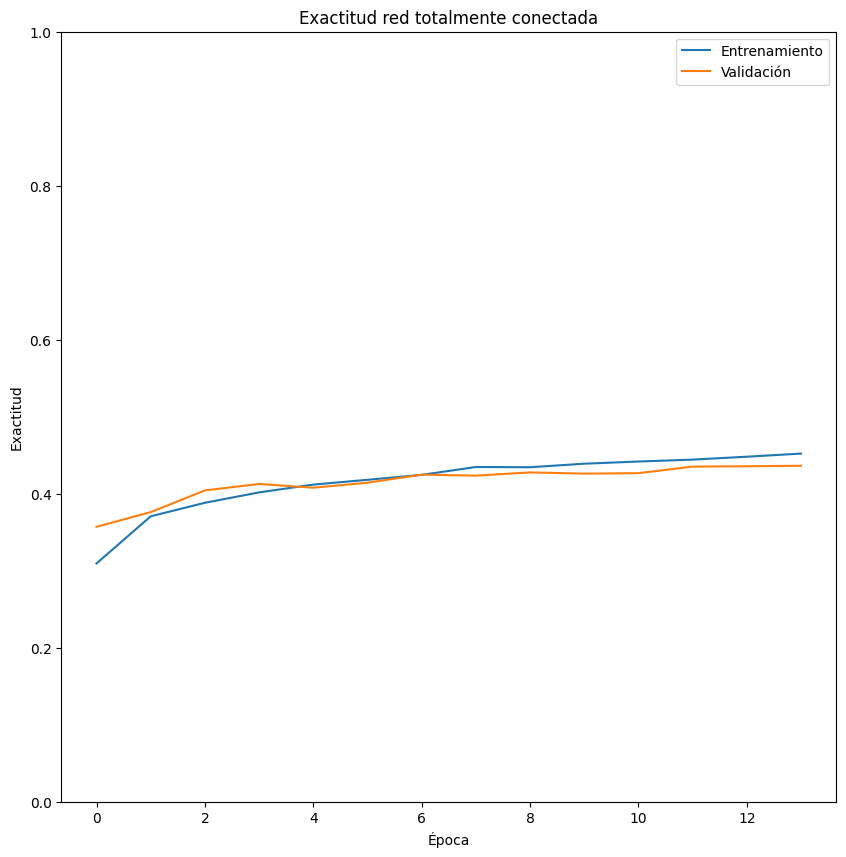

In [15]:
# Visualizamos Resultados - IMPORTANTE

plt.figure(figsize=(10,10))
plt.plot(history.history['accuracy'], label="Entrenamiento")
plt.plot(history.history['val_accuracy'], label="Validación")
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.title('Exactitud red totalmente conectada')
plt.legend()
plt.ylim([0, 1])

Finalmente, vamos a extraer métricas sobre el subconjunto de test. En primer lugar, deberemos de cargar el módelo óptimo, es decir, sobre el que hemos obtenido las mejores métricas en validación. Si no lo cargamos y hacemos uso directamente de "model", estaremos empleando los pesos obtenidos en la última época, en lugar de la época en la que mejores resultados hemos obtenido en validación.

In [16]:
# Extraemos métricas sobre el subconjunto de test
_, test_acc = model.evaluate(X_test, y_test, verbose=0)

print('Exactitud test:', test_acc)

Exactitud test: 0.4366999864578247


Podemos ver que el rendimiento que hemos obtenido con esta arquitectura es bastante bajo en todos los conjuntos de datos (entrenamiento, validación y test). Es decir, no se ha obtenido sobreajuste, pero una red neuronal totalmente conectada no es capaz de resolver este problema con precisión.

Por este motivo, surgen las redes neuronales convolucionales (CNN) que permiten preservar la imagen como matriz y, por tanto, tener en cuenta relaciones, no solo unidimensionales, sino también bidimensionales (o tridimensionales!)

## Red Neuronal Convolucional

Ya hemos visto la principal limitación de emplear un red totalmente conectada para la clasificación de imágenes. Otra aproximación que podríamos tomar es, en lugar de introducir la imagen origen a la red neuronal, previamente extraer características de ésta (filtros, autocodificadores, entre otros) y emplear éstas como entrada al clasificador. Sin embargo, esta fase de extracción de características se puede embeber dentro de la propia red para que esta fase también se ajuste durante el entrenamiento. Esto lo podemos conseguir gracias a las redes neuronales convolucionales, donde, a través de los filtros convolucionales, se extraen características a distintos niveles.

A continuación, vamos a tratar de resolver el mismo problema que antes pero empleando redes neuronales convolucionales.

In [17]:
def create_cnn_network():
    model = Sequential()
    model.add(Input(shape=X_train.shape[1:]))
    model.add(Conv2D(filters=24, kernel_size=(3,3), activation='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Conv2D(filters=36, kernel_size=(3,3), activation='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    return model

model_cnn = create_cnn_network()

model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 24)     │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 36)     │         7,812 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1296)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       166,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,790 (686.68 KB)

 Trainable params: 175,790 (686.68 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# 3 * 3 * 3 * 24 + 24

Vamos a observar y comparar el número de parámetros a entrenar de la red que hemos implementado previamente basada únicamente en capas totalmente conectadas y esta que además incluye filtros convolucionales.

- Red neuronal totalmente conectada: 394,634 parámetros
- Red neuronal convolucional: 175,790 parámetros.

Vemos que el número de parámetros a ajustar durante el entrenamiento se ha reducido a prácticamente la mitad, esto es porque, los filtros convolucionales no requieren un gran número de parámetros a entrenar, estos vienen principalmente, como se puede observar, de las capas totalmente conectadas, ya que hay un peso por conexión a ajustar. Dado que en las CNN el tamaño de las imágenes que se introducen a las capas totalmente conectadas es menor (6x6x36 en este caso frente a 32x32x3 en el anterior), el número de parámetros es también menor.

Número de parámetros a calcular de la primera capa convolucional:
(n_filas_filtro x n_columnas_filtro x n_canales_capa_anterior + 1) * n_filtros: (3x3x3+1)x24 = 672

In [19]:
# Compilamos el modelo

model_cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [20]:
# Inicializamos callback

model_checkpoint = ModelCheckpoint(
    filepath=os.path.join(models_path, 'cnn.keras'),  # Usar formato .keras
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,  # Guardar el modelo completo
    mode='max',
    verbose=1
)

In [21]:
# Inicializamos callback
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join(models_path, 'cnn.weights.h5'),  # Cambiar la extensión a .weights.h5
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    save_weights_only=True,  # Guardar solo los pesos
    verbose=1
)

In [22]:
history_cnn = model_cnn.fit(X_train, y_train, batch_size=64, epochs=20,
                            validation_data=(X_val, y_val),
                            verbose=1)
#model.save(os.path.join(models_path, 'cnn.h5'))

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.3368 - loss: 1.8197 - val_accuracy: 0.5411 - val_loss: 1.3139
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5449 - loss: 1.2839 - val_accuracy: 0.5926 - val_loss: 1.1493
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6126 - loss: 1.0991 - val_accuracy: 0.6136 - val_loss: 1.0991
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6504 - loss: 1.0146 - val_accuracy: 0.6372 - val_loss: 1.0348
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6738 - loss: 0.9357 - val_accuracy: 0.6566 - val_loss: 1.0061
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7008 - loss: 0.8609 - val_accuracy: 0.6685 - val_loss: 0.9731
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7192 - loss: 0.8152 - val_accuracy: 0.6624 - val_loss: 0.9810
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7401 - loss: 0.7578 - val_accuracy: 0.

(0.0, 1.0)

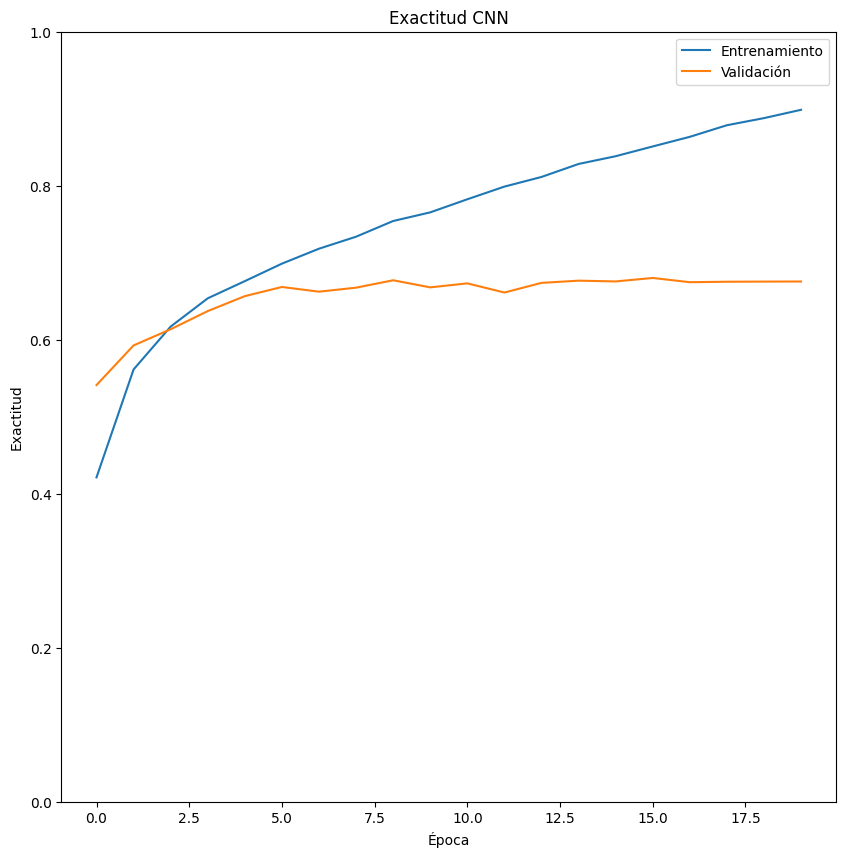

In [23]:
# Visualizamos los resultados
plt.figure(figsize=(10,10))
plt.plot(history_cnn.history['accuracy'], label="Entrenamiento")
plt.plot(history_cnn.history['val_accuracy'], label="Validación")
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.title('Exactitud CNN')
plt.legend()
plt.ylim([0, 1])

Aquí tenemos un claro ejemplo de sobreajuste en el que la curva de aprendizaje se estabiliza (en 0.68 aprox), y la curva de entrenamiento continua creciendo desde 0.73 (primera vez que se alcanza 0.68 en validación) hasta 0.88 (final del entrenamiento).

In [24]:
# Analizamos el rendimiento del modelo en test para establecer el punto de partida
_, acc_cnn = model_cnn.evaluate(X_test, y_test, verbose=0)
print('Exactitud CNN en test: ', acc_cnn)
print('Exactitud NN en test: ', test_acc)

Exactitud CNN en test:  0.6682000160217285
Exactitud NN en test:  0.4366999864578247


Igualmente podemos observar que hemos mejorado considerablemente el rendimiento del modelo con respecto los resultados obtenidos con la red neuronal totalmente conectada.

Vamos a realizar variaciones de la arquitectura para analizar si podemos mejorar el rendimiento del modelo. Para reducir el tiempo de entrenamiento para las evaluaciones emplearemos 8 épocas.

### Tamaño de lote

Vamos a evaluar los efectos de diferentes tamaños de lote. Además. para cada prueba vamos a calcular el tiempo total de entrenamiento haciendo uso de la librería *time*.

In [25]:
models_batch = {}
histories_batch = {}
times_batch = {}

batches = [10, 20, 50, 100, 200, 500, 1000]

for batch in batches:

  print(f'Entrenando con tamaño de batch: {batch}')

  ini = time.time()

  # Implementamos arquitectura
  models_batch['bs_' + str(batch)] = create_cnn_network()

  # Compilamos
  models_batch['bs_' + str(batch)].compile(optimizer='adam',
                                 loss='sparse_categorical_crossentropy',
                                 metrics=['accuracy'])

  # Inicializamos callback
  model_checkpoint = ModelCheckpoint(
      filepath=os.path.join(models_path, 'cnn_bs_' + str(batch) + '.weights.h5'),  # Extensión .weights.h5
      monitor='val_accuracy',
      mode='max',
      save_best_only=True,
      save_weights_only=True,  # Guardar solo pesos
      verbose=0)

  # Entrenamos
  histories_batch['bs_' + str(batch)] = models_batch['bs_' + str(batch)].fit(
      X_train, y_train,
      batch_size=batch,
      epochs=8,
      callbacks=[model_checkpoint],
      validation_data=(X_val, y_val),
      verbose=0)

  # Almacenamos tiempo entrenamiento
  times_batch['bs_' + str(batch)] = time.time() - ini

  # Garbage collector. Por lo general no hace falta, pero, dado que contamos
  # con poca RAM vamos a limpiarla tras cada entrenamiento para evitar que el
  # kernel se pare por falta de memoria
  gc.collect()

Entrenando con tamaño de batch: 10
Entrenando con tamaño de batch: 20
Entrenando con tamaño de batch: 50
Entrenando con tamaño de batch: 100
Entrenando con tamaño de batch: 200
Entrenando con tamaño de batch: 500
Entrenando con tamaño de batch: 1000


(0.0, 1.0)

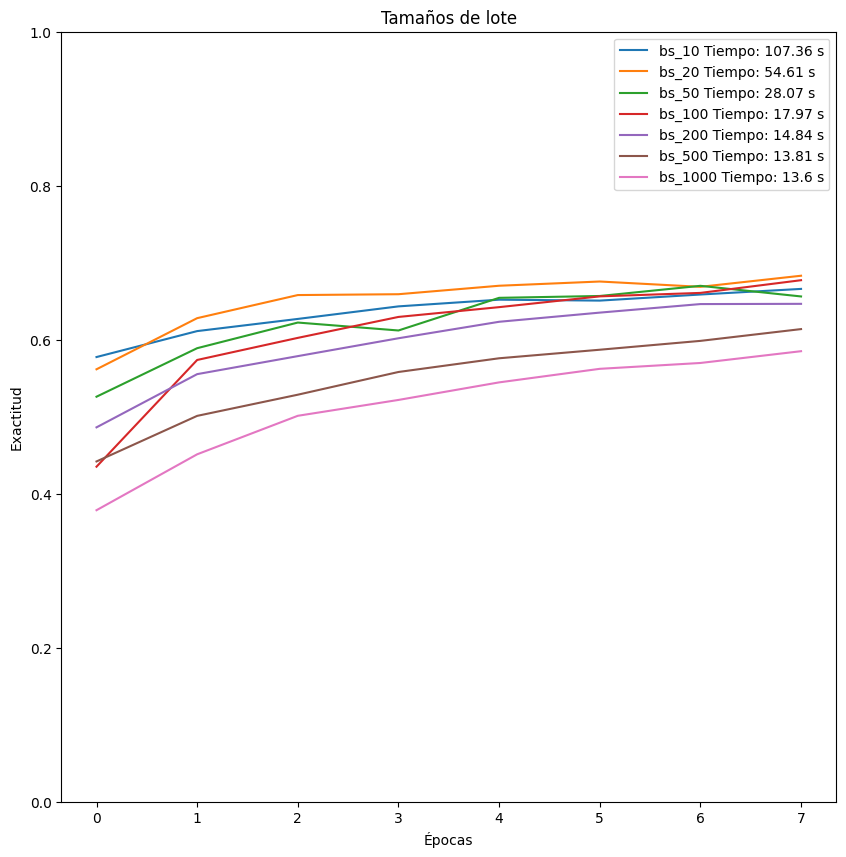

In [26]:
# Representamos curvas validación y tiempo de ejecución de cada modelo
plt.figure(figsize=(10,10))
for bs in histories_batch.keys():

  plt.plot(histories_batch[bs].history['val_accuracy'], label=bs + ' Tiempo: ' + str(np.round(times_batch[bs], 2)) + ' s')

plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.title('Tamaños de lote')
plt.legend()
plt.ylim([0, 1])

**NOTA**: Los números que aparecen aquí pueden variar ligeramente entre ejecuciones

Podemos ver como con tamaños de lote hasta 100/200 se obtienen resultados similares en validación, sin embargo, el tiempo de ejecución es significativamente menor cuanto mayor es el tamaño de lote (105s para tamaño de lote de 10 vs. 21s para tamaño de lote de 100). Sin embargo, con tamaños de lote más elevados, la precisión disminuye.

Sigamos explorando los resultados.

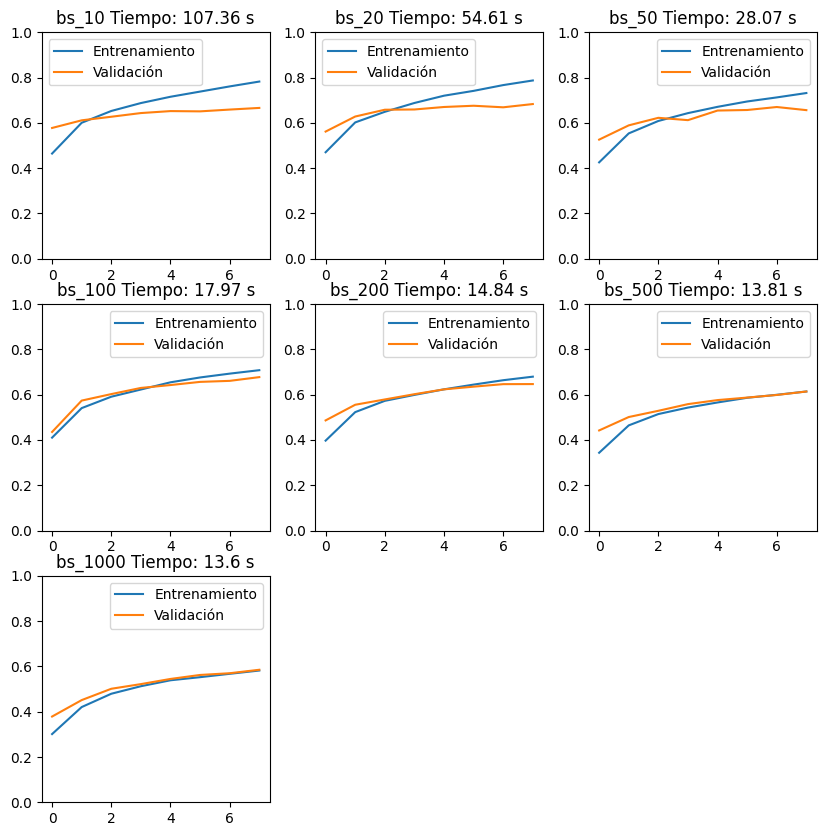

In [27]:
# Representamos curvas entrenamiento y validación para cada tamaño de lote y
# el tiempo de entrenamiento
plt.figure(figsize=(10,10))
for i, bs in enumerate(histories_batch.keys()):
  plt.subplot(3, 3, i+1)
  plt.plot(histories_batch[bs].history['accuracy'], label='Entrenamiento')
  plt.plot(histories_batch[bs].history['val_accuracy'], label='Validación')
  # Incluimos tiempo de entrenamiento en el titulo
  plt.title(f'{bs} Tiempo: {np.round(times_batch[bs], 2)} s')
  plt.legend()
  plt.ylim([0,1])

De las gráficas anteriores podemos observar que con tamaños de lote bajos (10) tenemos un sobreajuste del modelo a los datos de entrenamiento.

Veamos que ocurre en test.

In [28]:
for bs_key in models_batch.keys():
    # Eliminar el prefijo 'bs_' de la clave
    bs = bs_key.replace('bs_', '')  # Solo queda el número del batch size

    # Generar la ruta correcta
    file_path = os.path.join(models_path, f'cnn_bs_{bs}.weights.h5')

    # Verificar si el archivo existe
    if os.path.exists(file_path):
        print(f"Cargando pesos para batch size {bs} desde: {file_path}")

        # Reconstruir la arquitectura del modelo
        model_bs = create_cnn_network()

        # Cargar los pesos guardados
        model_bs.load_weights(file_path)

        # Compilar el modelo
        model_bs.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # Evaluar en el conjunto de prueba
        _, acc = model_bs.evaluate(X_test, y_test, verbose=0)
        print(f'Exactitud test {bs}: {acc}')
    else:
        print(f"Archivo no encontrado: {file_path}")

Cargando pesos para batch size 10 desde: /content/models/cnn_bs_10.weights.h5
Exactitud test 10: 0.6588000059127808
Cargando pesos para batch size 20 desde: /content/models/cnn_bs_20.weights.h5
Exactitud test 20: 0.6832000017166138
Cargando pesos para batch size 50 desde: /content/models/cnn_bs_50.weights.h5
Exactitud test 50: 0.6715999841690063
Cargando pesos para batch size 100 desde: /content/models/cnn_bs_100.weights.h5
Exactitud test 100: 0.6769000291824341
Cargando pesos para batch size 200 desde: /content/models/cnn_bs_200.weights.h5
Exactitud test 200: 0.6507999897003174
Cargando pesos para batch size 500 desde: /content/models/cnn_bs_500.weights.h5
Exactitud test 500: 0.6105999946594238
Cargando pesos para batch size 1000 desde: /content/models/cnn_bs_1000.weights.h5
Exactitud test 1000: 0.5842000246047974


La mejor precisión se obtiene con un tamaño de lote de 20, sin embargo, con tamaños de lote mayores (500-1000), la precisión se disminuye considerablemente.

Sin embargo, viendo las gráficas anteriores. ¿Realmente creemos que con tamaños de lote elevados hemos llegado a la convergencia? ¿Debemos de ajustar los parámetros uno a uno o estos tienen dependencias entre si?

Ahora vamos a entrenar de nuevo los modelos anteriores pero esta vez emplearemos el callback de EarlyStopping (que ya vimos en la sesión anterior) para detener el entrenamiento en un valor de época apropiado (cuando las pérdidas en validación dejen de disminuir durante 5 épocas seguidas).

In [29]:
models_batch_stop = {}
histories_batch_stop = {}
times_batch_stop = {}

batches = [10, 20, 50, 100, 200, 500, 1000]

for batch in batches:

  print(f'Entrenando con tamaño de batch: {batch}')

  ini = time.time()

  earlystopping = EarlyStopping(monitor="val_loss",
                                                   mode="min", patience=5,
                                                   restore_best_weights=True,
                                                   verbose=1)

  models_batch_stop['bs_' + str(batch)] = create_cnn_network()

  models_batch_stop['bs_' + str(batch)].compile(optimizer='adam',
                                                loss='sparse_categorical_crossentropy',
                                                metrics=['accuracy'])


  model_checkpoint = ModelCheckpoint(
      filepath=os.path.join(models_path, 'cnn_bs_' + str(batch) + '.weights.h5'),  # Extensión .weights.h5
      monitor='val_accuracy',
      mode='max',
      save_best_only=True,
      save_weights_only=True,  # Guardar solo pesos
      verbose=0)

  histories_batch_stop['bs_' + str(batch)] = models_batch_stop['bs_' + str(batch)].fit(
      X_train, y_train,
      batch_size=batch,
      epochs=100,
      callbacks=[model_checkpoint, earlystopping],
      validation_data=(X_val, y_val),
      verbose=0)

  times_batch_stop['bs_' + str(batch)] = time.time() - ini

  gc.collect()


Entrenando con tamaño de batch: 10
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.
Entrenando con tamaño de batch: 20
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 6.
Entrenando con tamaño de batch: 50
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 8.
Entrenando con tamaño de batch: 100
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 12.
Entrenando con tamaño de batch: 200
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 15.
Entrenando con tamaño de batch: 500
Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 26.
Entrenando con tamaño de batch: 1000
Epoch 43: early stopping
Restoring model weights from the end of the best epoch: 38.


(0.0, 1.0)

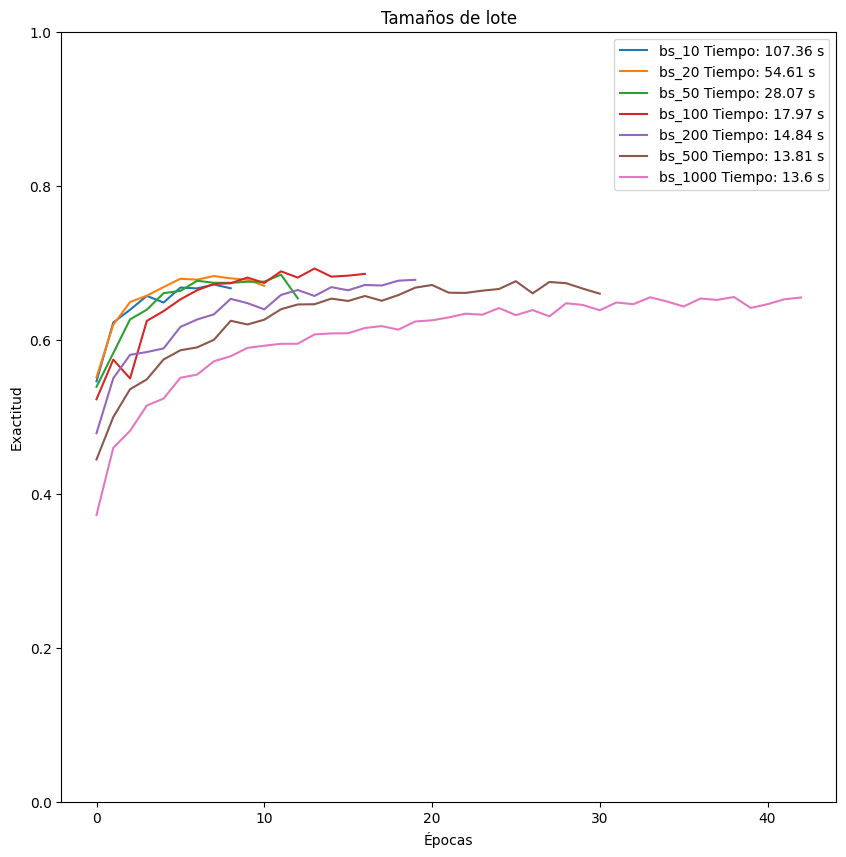

In [30]:
# Representamos curvas validación y tiempo de ejecución de cada modelo
plt.figure(figsize=(10,10))
for bs in histories_batch_stop.keys():

  plt.plot(histories_batch_stop[bs].history['val_accuracy'], label=bs + ' Tiempo: ' + str(np.round(times_batch[bs], 2)) + ' s')

plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.title('Tamaños de lote')
plt.legend()
plt.ylim([0, 1])

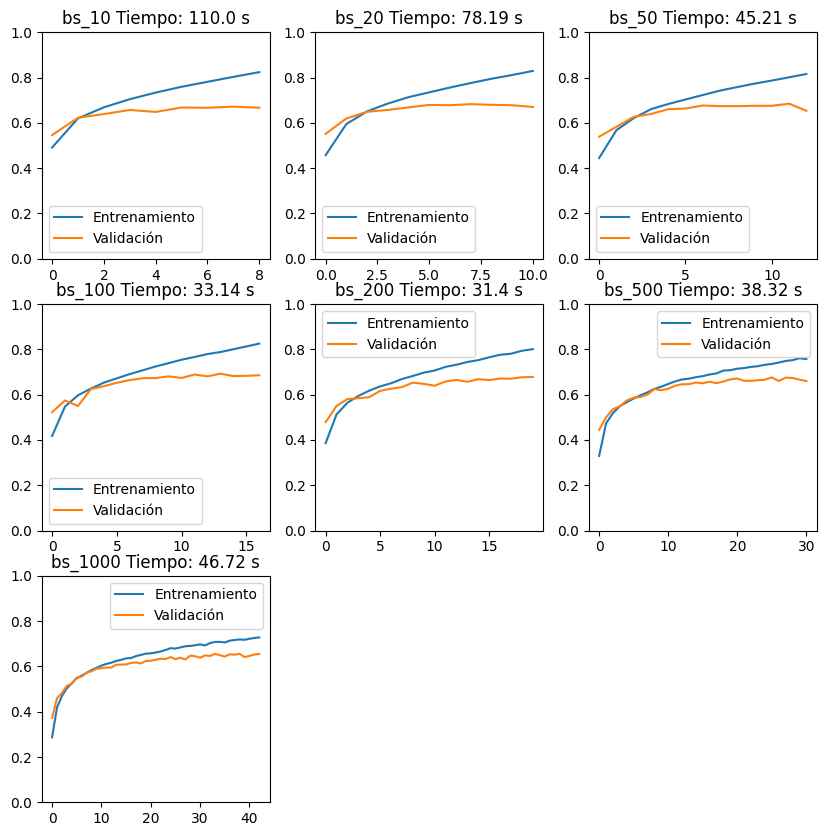

In [31]:
# Representamos curvas entrenamiento y validación para cada tamaño de lote y
# el tiempo de entrenamiento
plt.figure(figsize=(10,10))
for i, bs in enumerate(histories_batch_stop.keys()):
  plt.subplot(3, 3, i+1)
  plt.plot(histories_batch_stop[bs].history['accuracy'], label='Entrenamiento')
  plt.plot(histories_batch_stop[bs].history['val_accuracy'], label='Validación')
  # Incluimos tiempo de entrenamiento en el titulo
  plt.title(f'{bs} Tiempo: {np.round(times_batch_stop[bs], 2)} s')
  plt.legend()
  plt.ylim([0,1])

Ahora ya vemos que para tamaños de lote más altos, el modelo ha llegado a converger.
Vamos a ver que sucede en el conjunto de datos de test.

In [32]:
for bs_key in models_batch_stop.keys():
    # Eliminar prefijo 'bs_' para obtener el tamaño de batch
    bs = bs_key.replace('bs_', '')

    # Generar la ruta del archivo según los nombres disponibles
    file_path = os.path.join(models_path, f'cnn_bs_{bs}.weights.h5')

    # Verificar si el archivo existe
    if os.path.exists(file_path):
        print(f"Cargando pesos para batch size {bs} desde: {file_path}")

        # Reconstruir la arquitectura del modelo
        model_early = create_cnn_network()

        # Cargar los pesos guardados
        model_early.load_weights(file_path)

        # Compilar el modelo
        model_early.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # Evaluar en el conjunto de prueba
        _, acc = model_early.evaluate(X_test, y_test, verbose=0)

        # Obtener datos de historia y tiempo
        if bs_key in histories_batch_stop and bs_key in times_batch_stop:
            n_epochs = len(histories_batch_stop[bs_key].history['accuracy'])
            ex_time = times_batch_stop[bs_key]
            print(f'Exactitud test {bs}: {acc:.4f}; N épocas: {n_epochs}; Tiempo: {ex_time:.2f} s')
        else:
            print(f"Datos de historia o tiempo no encontrados para batch size {bs}.")
    else:
        print(f"Archivo no encontrado: {file_path}")


Cargando pesos para batch size 10 desde: /content/models/cnn_bs_10.weights.h5
Exactitud test 10: 0.6729; N épocas: 9; Tiempo: 110.00 s
Cargando pesos para batch size 20 desde: /content/models/cnn_bs_20.weights.h5
Exactitud test 20: 0.6767; N épocas: 11; Tiempo: 78.19 s
Cargando pesos para batch size 50 desde: /content/models/cnn_bs_50.weights.h5
Exactitud test 50: 0.6803; N épocas: 13; Tiempo: 45.21 s
Cargando pesos para batch size 100 desde: /content/models/cnn_bs_100.weights.h5
Exactitud test 100: 0.6928; N épocas: 17; Tiempo: 33.14 s
Cargando pesos para batch size 200 desde: /content/models/cnn_bs_200.weights.h5
Exactitud test 200: 0.6732; N épocas: 20; Tiempo: 31.40 s
Cargando pesos para batch size 500 desde: /content/models/cnn_bs_500.weights.h5
Exactitud test 500: 0.6777; N épocas: 31; Tiempo: 38.32 s
Cargando pesos para batch size 1000 desde: /content/models/cnn_bs_1000.weights.h5
Exactitud test 1000: 0.6565; N épocas: 43; Tiempo: 46.72 s


Podemos ver como ahora han cambiado considerablemente los resultados. Resultados similares se obtienen con diferentes tamaños de lote, sin embargo, el tiempo de entrenamiento cambia.

Podemos ver que la combinación que mejores resultados ofrece es emplear un tamaño de lote de 100 y entrenar a lo largo de 15 épocas. Lo que supone un tiempo de entrenamiento de 66 segundos. Sin embargo, los resultados que se obtienen con un tamaño de lote de 20 son similares, sin embargo el tiempo de ejecución aumenta.

En este caso no nos encontramos este escenario, pero en otras ocasiones en la que tengamos conjuntos de datos más grandes o imágenes de mayor resolución, puede darse el caso que merezca la pena prescindir de un poco de precisión a favor de un menor tiempo de entrenamiento.

Para siguientes experimentos vamos a mantener tamaño de lote 100 y EarlyStopping.

### Añadimos filtros a las capas convolucionales

Vamos a incrementar la complejidad de la arquitectura para comprobar si mejoramos los resultados. Vamos a mantener dos capas convolucionales pero esta vez con 128 y 256 filtros respectivamente.

In [33]:
def create_cnn_network_filters():
    model = Sequential()
    model.add(Input(shape=X_train.shape[1:]))
    model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    return model

model_cnn_filters = create_cnn_network_filters()

model_cnn_filters.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

earlystopping = EarlyStopping(monitor="val_loss",
                                                 mode="min", patience=5,
                                                 restore_best_weights=True,
                                                 verbose=1)


model_checkpoint = ModelCheckpoint(
    filepath=os.path.join(models_path, 'cnn_filters.keras'),  # Guardar modelo completo
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

history_filters = model_cnn_filters.fit(X_train, y_train, batch_size=100,
                                        epochs=50,
                                        callbacks=[model_checkpoint, earlystopping],
                                        validation_data=(X_val, y_val),
                                        verbose=0)



Epoch 1: val_accuracy improved from -inf to 0.55460, saving model to /content/models/cnn_filters.keras

Epoch 2: val_accuracy improved from 0.55460 to 0.61980, saving model to /content/models/cnn_filters.keras

Epoch 3: val_accuracy improved from 0.61980 to 0.64430, saving model to /content/models/cnn_filters.keras

Epoch 4: val_accuracy improved from 0.64430 to 0.68140, saving model to /content/models/cnn_filters.keras

Epoch 5: val_accuracy improved from 0.68140 to 0.69400, saving model to /content/models/cnn_filters.keras

Epoch 6: val_accuracy improved from 0.69400 to 0.69680, saving model to /content/models/cnn_filters.keras

Epoch 7: val_accuracy improved from 0.69680 to 0.71130, saving model to /content/models/cnn_filters.keras

Epoch 8: val_accuracy did not improve from 0.71130

Epoch 9: val_accuracy improved from 0.71130 to 0.71370, saving model to /content/models/cnn_filters.keras

Epoch 10: val_accuracy improved from 0.71370 to 0.71620, saving model to /content/models/cnn_f

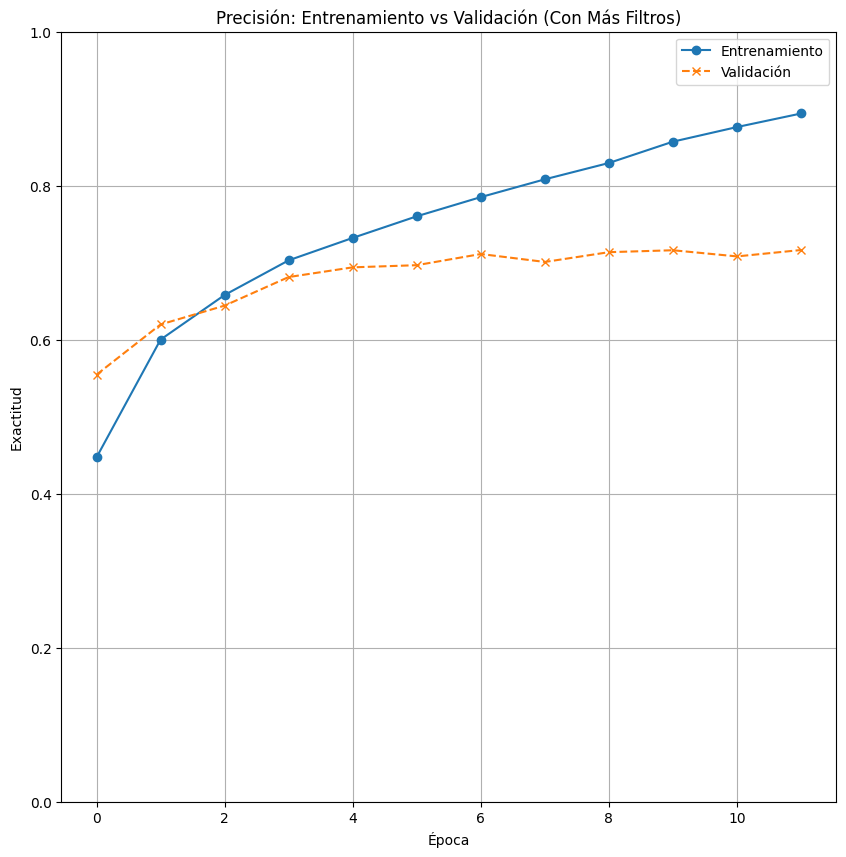

In [34]:
# Crear la figura
plt.figure(figsize=(10, 10))

# Graficar precisión de entrenamiento y validación
plt.plot(history_filters.history['accuracy'], label='Entrenamiento', linestyle='-', marker='o')
plt.plot(history_filters.history['val_accuracy'], label='Validación', linestyle='--', marker='x')

# Etiquetas y título
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.title('Precisión: Entrenamiento vs Validación (Con Más Filtros)')
plt.legend()

# Limitar el eje y
plt.ylim([0, 1])

# Mostrar la cuadrícula y la gráfica
plt.grid(True)
plt.show()

(0.0, 1.0)

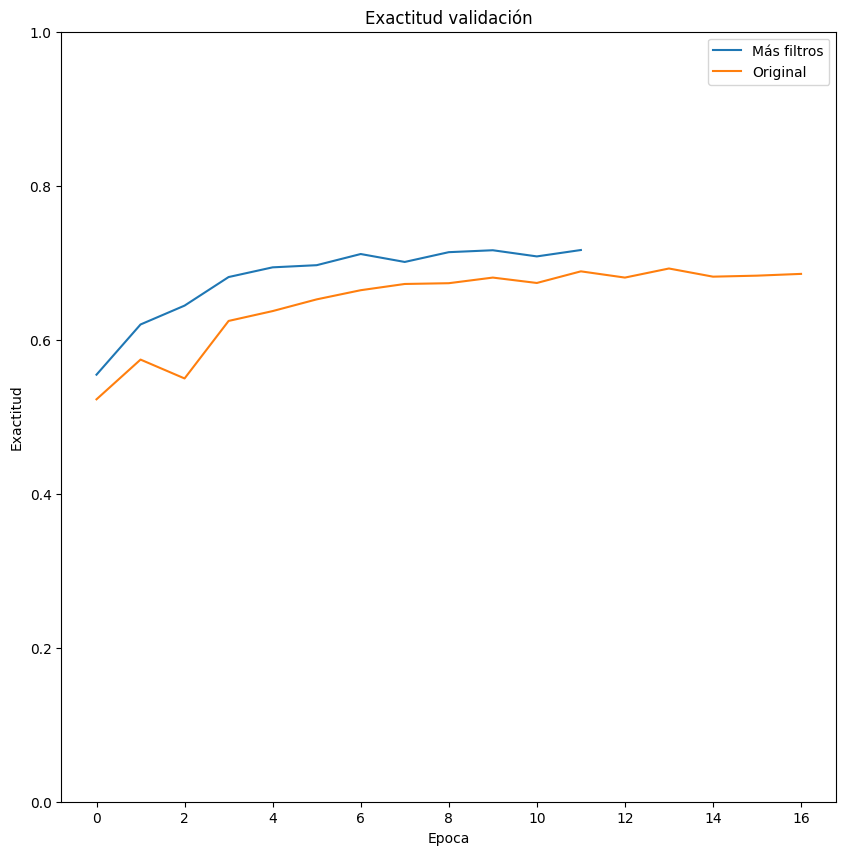

In [35]:
plt.figure(figsize=(10,10))
plt.plot(history_filters.history['val_accuracy'], label='Más filtros')
plt.plot(histories_batch_stop['bs_100'].history['val_accuracy'], label='Original')
plt.xlabel('Epoca')
plt.ylabel('Exactitud')
plt.title('Exactitud validación')
plt.legend()
plt.ylim([0,1])

In [36]:
models_path = '/content/models'  # Asegúrate de que esta variable esté definida correctamente
print("Archivos disponibles en models_path:")
print(os.listdir(models_path))
# Vamos a comparar la exactitud en test
model_cnn_filters = tf.keras.models.load_model(os.path.join(models_path, 'cnn_filters.keras'))

# Evaluar o usar para predicción
_, acc_filters = model_cnn_filters.evaluate(X_test, y_test, verbose=0)
print('Exactitud test añadiendo más filtros: ', acc_filters)

Archivos disponibles en models_path:
['cnn_bs_1000.weights.h5', 'dnn.keras', 'cnn_bs_500.weights.h5', 'cnn_bs_200.weights.h5', 'cnn_bs_100.weights.h5', 'cnn_bs_50.weights.h5', 'cnn_bs_10.weights.h5', 'cnn_bs_20.weights.h5', 'cnn_filters.keras']
Exactitud test añadiendo más filtros:  0.7153000235557556


Añadiendo filtros se obtiene una ligera mejora en la precisión obtenida sobre el conjunto de imágenes de test.

### Añadimos más capas convolucionales

A continuación, vamos a evaluar los efectos de incorporar más capas convolucionales al modelo (ampliamos la complejidad del modelo).

In [37]:
def create_cnn_network_layers():
    model = Sequential()
    model.add(Input(shape=X_train.shape[1:]))
    model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    return model

model_cnn_layers = create_cnn_network_layers()

model_cnn_layers.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_60 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_31 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,772,106 (33.46 MB)

 Trainable params: 8,772,106 (33.46 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model_cnn_layers.compile(optimizer='adam',
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

earlystopping = EarlyStopping(monitor="val_loss",
                              mode="min", patience=5,
                              restore_best_weights=True,
                              verbose=1)


model_checkpoint = ModelCheckpoint(
    filepath=os.path.join(models_path, 'cnn_filters.weights.h5'),  # Cambiar a .weights.h5 para indicar que son solo pesos
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,  # Guarda solo el mejor modelo basado en 'val_accuracy'
    save_weights_only=True,  # Indica que solo se guardarán los pesos
    verbose=1
)


history_layers = model_cnn_layers.fit(X_train, y_train, batch_size=100,
                                      epochs=50,
                                      callbacks=[model_checkpoint, earlystopping],
                                      validation_data=(X_val, y_val),
                                      verbose=0)


Epoch 1: val_accuracy improved from -inf to 0.50390, saving model to /content/models/cnn_filters.weights.h5

Epoch 2: val_accuracy improved from 0.50390 to 0.64550, saving model to /content/models/cnn_filters.weights.h5

Epoch 3: val_accuracy improved from 0.64550 to 0.68880, saving model to /content/models/cnn_filters.weights.h5

Epoch 4: val_accuracy improved from 0.68880 to 0.72160, saving model to /content/models/cnn_filters.weights.h5

Epoch 5: val_accuracy improved from 0.72160 to 0.74800, saving model to /content/models/cnn_filters.weights.h5

Epoch 6: val_accuracy improved from 0.74800 to 0.75740, saving model to /content/models/cnn_filters.weights.h5

Epoch 7: val_accuracy improved from 0.75740 to 0.76810, saving model to /content/models/cnn_filters.weights.h5

Epoch 8: val_accuracy did not improve from 0.76810

Epoch 9: val_accuracy improved from 0.76810 to 0.76850, saving model to /content/models/cnn_filters.weights.h5

Epoch 10: val_accuracy did not improve from 0.76850

E

(0.0, 1.0)

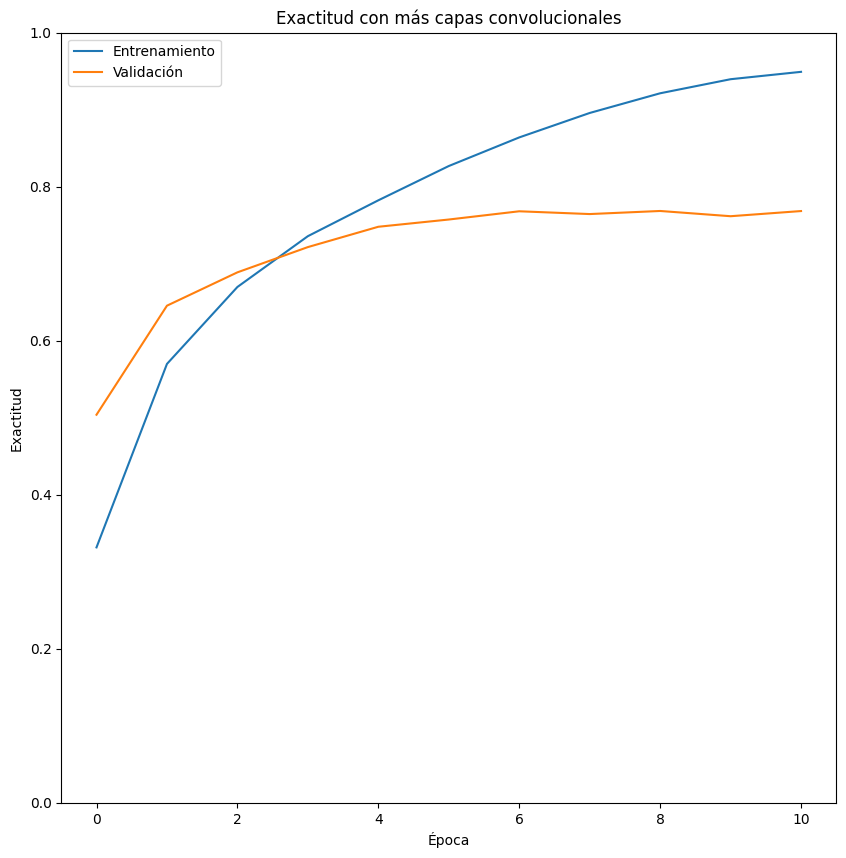

In [39]:
plt.figure(figsize=(10,10))
plt.plot(history_layers.history['accuracy'], label='Entrenamiento')
plt.plot(history_layers.history['val_accuracy'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.title('Exactitud con más capas convolucionales')
plt.legend()
plt.ylim([0,1])

In [40]:
models_path = '/content/models'  # Asegúrate de que esta variable esté correctamente definida
print("Archivos disponibles en models_path:")
print(os.listdir(models_path))

# Reconstruir la arquitectura
model_cnn_layers = create_cnn_network_layers()

# Cargar los pesos guardados
model_cnn_layers.load_weights(os.path.join(models_path, 'cnn_filters.weights.h5'))

# Compilar el modelo (necesario antes de evaluación/predicción)
model_cnn_layers.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluar en el conjunto de prueba
_, acc_layers = model_cnn_layers.evaluate(X_test, y_test, verbose=0)
print('Exactitud en el conjunto de prueba: ', acc_layers)


Archivos disponibles en models_path:
['cnn_bs_1000.weights.h5', 'dnn.keras', 'cnn_bs_500.weights.h5', 'cnn_bs_200.weights.h5', 'cnn_bs_100.weights.h5', 'cnn_filters.weights.h5', 'cnn_bs_50.weights.h5', 'cnn_bs_10.weights.h5', 'cnn_bs_20.weights.h5', 'cnn_filters.keras']
Exactitud en el conjunto de prueba:  0.7613000273704529


En esta ocación, observamos una mejora en el rendimiento del modelo al aumentar el número de capas. Vamos a emplear este último modelo como referencia para siguientes comparaciones de modelos.

### Regularización

En esta parte de la práctiva vamos a ver diferentes formas de introducir regularización al modelo, es decir, disminuir la complejidad del mismo.

La primera técnica que vamos a evaluar es el uso de dropout en las capas totalmente conectadas. Si recordamos de la sesión anterior, esta es la técnica según la cual en cada época, un porcentaje determinado de neuronas se apagan (pudiéndose diferentes entre épocas aquellas afectadas)

In [41]:
def create_cnn_network_dropout():
    model = Sequential()
    model.add(Input(shape=X_train.shape[1:]))
    model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    # Añadimos capa de regularización basada en Dropout
    model.add(Dropout(0.25))
    model.add(Dense(10, activation='softmax'))

    return model

model_cnn_dropout = create_cnn_network_dropout()

model_cnn_dropout.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

model_checkpoint = ModelCheckpoint(
    filepath=os.path.join(models_path, 'cnn_dropout.weights.h5'),  # Cambiar a .weights.h5 para indicar que son solo pesos
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,  # Guarda solo el mejor modelo basado en 'val_accuracy'
    save_weights_only=True,  # Indica que solo se guardarán los pesos
    verbose=1
)

earlystopping = EarlyStopping(monitor="val_loss",
                              mode="min", patience=2,
                              restore_best_weights=True,
                              verbose=1)

history_dropout = model_cnn_dropout.fit(X_train, y_train, batch_size=100,
                                        epochs=50,
                                        callbacks=[model_checkpoint, earlystopping],
                                        validation_data=(X_val, y_val),
                                        verbose=0)


Epoch 1: val_accuracy improved from -inf to 0.48090, saving model to /content/models/cnn_dropout.weights.h5

Epoch 2: val_accuracy improved from 0.48090 to 0.60090, saving model to /content/models/cnn_dropout.weights.h5

Epoch 3: val_accuracy improved from 0.60090 to 0.66720, saving model to /content/models/cnn_dropout.weights.h5

Epoch 4: val_accuracy improved from 0.66720 to 0.71120, saving model to /content/models/cnn_dropout.weights.h5

Epoch 5: val_accuracy improved from 0.71120 to 0.73510, saving model to /content/models/cnn_dropout.weights.h5

Epoch 6: val_accuracy improved from 0.73510 to 0.75300, saving model to /content/models/cnn_dropout.weights.h5

Epoch 7: val_accuracy improved from 0.75300 to 0.76460, saving model to /content/models/cnn_dropout.weights.h5

Epoch 8: val_accuracy improved from 0.76460 to 0.76930, saving model to /content/models/cnn_dropout.weights.h5

Epoch 9: val_accuracy did not improve from 0.76930

Epoch 10: val_accuracy improved from 0.76930 to 0.7698

(0.0, 1.0)

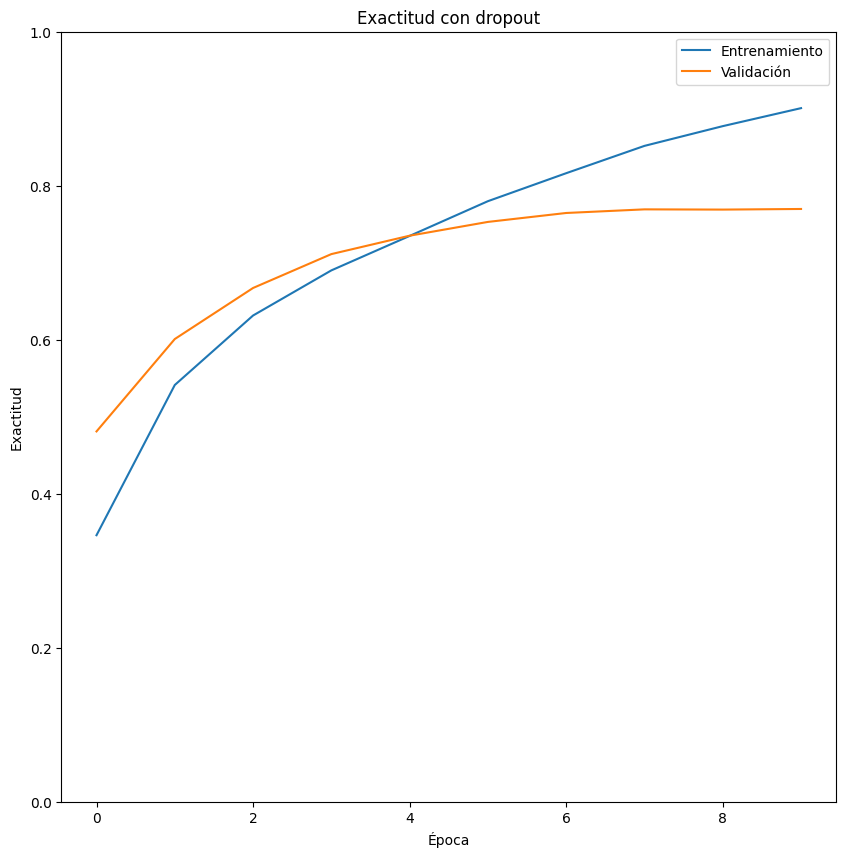

In [42]:
plt.figure(figsize=(10,10))
plt.plot(history_dropout.history['accuracy'], label='Entrenamiento')
plt.plot(history_dropout.history['val_accuracy'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.title('Exactitud con dropout')
plt.legend()
plt.ylim([0,1])

In [43]:
models_path = '/content/models'  # Asegúrate de que esta variable esté correctamente definida
print("Archivos disponibles en models_path:")
print(os.listdir(models_path))

# Reconstruir la arquitectura
model_cnn_layers = create_cnn_network_layers()

# Cargar los pesos guardados
model_cnn_layers.load_weights(os.path.join(models_path, 'cnn_dropout.weights.h5'))

# Compilar el modelo (necesario antes de evaluación/predicción)
model_cnn_layers.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluar en el conjunto de prueba
_, acc_layers = model_cnn_layers.evaluate(X_test, y_test, verbose=0)
print('Exactitud en el conjunto de prueba: ', acc_layers)

Archivos disponibles en models_path:
['cnn_bs_1000.weights.h5', 'dnn.keras', 'cnn_bs_500.weights.h5', 'cnn_bs_200.weights.h5', 'cnn_bs_100.weights.h5', 'cnn_dropout.weights.h5', 'cnn_filters.weights.h5', 'cnn_bs_50.weights.h5', 'cnn_bs_10.weights.h5', 'cnn_bs_20.weights.h5', 'cnn_filters.keras']
Exactitud en el conjunto de prueba:  0.7595000267028809


Vemos que se produce una pequeña mejora en la exactitud del modelo al emplear dropout.

Lo siguiente que vamos a probar es incorporar batch normalization (normalización por batches) tras cada filtro convolucional. Esta [capa](https://keras.io/api/layers/normalization_layers/batch_normalization/) ha demostrado grandes resultados en la mejora de la generalización de los modelos y se basa en normalizar la salida del filtro convolucional empleando la media y desviación estandar de ésta.

In [44]:
def create_cnn_network_bn():
    model = Sequential()
    model.add(Input(shape=X_train.shape[1:]))
    model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=512, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    return model

model_cnn_bn = create_cnn_network_bn()

model_cnn_bn.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])




model_checkpoint = ModelCheckpoint(
    filepath=os.path.join(models_path, 'cnn_batch_normalization.weights.h5'),  # Cambiar a .weights.h5 para indicar que son solo pesos
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,  # Guarda solo el mejor modelo basado en 'val_accuracy'
    save_weights_only=True,  # Indica que solo se guardarán los pesos
    verbose=1
)

earlystopping = EarlyStopping(monitor="val_loss",
                              mode="min", patience=5,
                              restore_best_weights=True,
                              verbose=1)

history_bn = model_cnn_bn.fit(X_train, y_train, batch_size=100,
                              epochs=50,
                              callbacks=[model_checkpoint, earlystopping],
                              validation_data=(X_val, y_val),
                              verbose=0)


Epoch 1: val_accuracy improved from -inf to 0.20150, saving model to /content/models/cnn_batch_normalization.weights.h5

Epoch 2: val_accuracy improved from 0.20150 to 0.65220, saving model to /content/models/cnn_batch_normalization.weights.h5

Epoch 3: val_accuracy improved from 0.65220 to 0.73750, saving model to /content/models/cnn_batch_normalization.weights.h5

Epoch 4: val_accuracy improved from 0.73750 to 0.75390, saving model to /content/models/cnn_batch_normalization.weights.h5

Epoch 5: val_accuracy improved from 0.75390 to 0.76940, saving model to /content/models/cnn_batch_normalization.weights.h5

Epoch 6: val_accuracy improved from 0.76940 to 0.78150, saving model to /content/models/cnn_batch_normalization.weights.h5

Epoch 7: val_accuracy did not improve from 0.78150

Epoch 8: val_accuracy did not improve from 0.78150

Epoch 9: val_accuracy did not improve from 0.78150
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.


NameError: name 'plt' is not defined

Vemos que no ha habido mejora introduciendo batch normalization.

A continuación, vamos a probar los dos métodos anteriores (dropout y batch normalization). En la mayoría de las ocasiones no va a ser un único método el que nos ofrezca los mejores resultados sino una combinación de varios.

### Visualización filtros convolucionales y mapas de características

En esta sección vamos visualizar qué es lo que estamos entrenando y en qué se fija la CNN a la hora de realizar una predicción.

Para ello, en primer lugar, con la última CNN entrenada vamos a visualizar los filtros que hemos entrenado así como, empleando una de las imágenes de test, ver en qué se fija de esta para realizar la preducción.

Visualizamos las capas que forman nuestra CNN

De nuestra arquitectura vamos a ver qué capas corresponden con los filtros convolucionales y el tamaño de estos.

Vemos que todas las capas convolucionales tienen filtros de 3x3. La profundidad que estos muestran es igual a la profundidad de la imagen de entrada.

Vamos a visualizar los filtros de la primera capa convolucional.

Tenemos 128 filtros de 3x3x3. Vamos a visualizar los 6 primeros filtros y vamos a representar los 3 canales por separado ya que los pesos que se aplican a cada canal de entrada son independientes y diferentes entre si.

A continuación vamos a visualizar los mapas de características generados por los filtros convolucionales dada una imagen de entrada.

Vamos a seleccionar una imagen del set de test.

Podemos observar como algunos filtros generan mapas de características que destacan los bordes

Nuestra CNN está formada por 3 bloques principales formados, cada uno, por dos capas convolucionales. Vamos a visualizar los mapas de características a la salida de estos bloques.